Problem Set 2: Number of Fraudulent Transactions Flagged
Problem Statement

A fraud-detection model examines 50 transactions every hour.

Each transaction has a probability of:

$$ p=0.04 $$

of being flagged as potentially fraudulent.

Let:

$$ X=\text{number of transactions flagged in one hour} $$

Assuming individual flagging decisions are independent:

$$ X\sim Binomial(n=50,p=0.04) $$

The fraud investigation team can examine at most four flagged transactions per hour.

Step 1: Identify the Random Variable

Here, \(X\) represents the total number of transactions flagged during one hour.

Unlike Problem Set 1, \(X\) can have more than two possible values.

Since 50 transactions are examined:

$$ X\in\{0,1,2,\ldots,50\} $$

The appropriate distribution is the Binomial distribution.

$$ X\sim Binomial(50,0.04) $$

Step 2: Simulate 20,000 Independent One-Hour Periods

Each simulated hour consists of:

50 transactions

Probability of flagging = 0.04
\(X\) = number of flagged transaction

Here we See Number of Hours = 20,000

In [2]:
import numpy as np
n_transactions = 50
p_flag = 0.04
n_hours = 20_000

flagged_transactions = np.random.binomial(
    n=n_transactions,
    p=p_flag,
    size=n_hours
)

print("Number of simulated hours:", len(flagged_transactions))
print("First 20 simulated hours:")
print(flagged_transactions[:20])


Number of simulated hours: 20000
First 20 simulated hours:
[3 3 2 2 1 2 3 4 3 1 5 5 1 3 2 3 0 0 0 1]


Step 3: Basic Statistics of the Simulation

In [3]:
print("Mean number of flagged transactions:",
      np.mean(flagged_transactions))

print("Variance:",
      np.var(flagged_transactions))

print("Minimum:",
      np.min(flagged_transactions))

print("Maximum:",
      np.max(flagged_transactions))

Mean number of flagged transactions: 1.99575
Variance: 1.9228319374999998
Minimum: 0
Maximum: 11


Step 4: Theoretical Mean and Variance

For a Binomial random variable:

$$ E[X]=np $$

Therefore:

$$ E[X]=50(0.04)=2 $$

So, on average, 2 transactions are expected to be flagged per hour.

The theoretical variance is:

$$ Var(X)=np(1-p) $$ $$ Var(X)=50(0.04)(0.96) $$ $$ Var(X)=1.92 $$

In [4]:
theoretical_mean_binomial = n_transactions * p_flag

theoretical_variance_binomial = (
    n_transactions * p_flag * (1 - p_flag)
)

print("Theoretical mean:", theoretical_mean_binomial)
print("Theoretical variance:", theoretical_variance_binomial)

Theoretical mean: 2.0
Theoretical variance: 1.92


Step 5: Investigation Capacity

The investigation team can examine at most 4 flagged transactions per hour.

Therefore:

\(X < 4\) → Team capacity is sufficient.
\(X > 4\) → Team capacity is exceeded.

In [5]:
capacity = 4

hours_within_capacity = np.sum(
    flagged_transactions <= capacity
)

hours_exceeding_capacity = np.sum(
    flagged_transactions > capacity
)

print("Hours within capacity:", hours_within_capacity)
print("Hours exceeding capacity:", hours_exceeding_capacity)

Hours within capacity: 19034
Hours exceeding capacity: 966


Step 6: Empirical Probability of Exceeding Capacity

We can estimate the probability that more than four transactions are flagged:

P(X>4)

In [6]:
empirical_probability_exceeding = np.mean(
    flagged_transactions > capacity
)

print(
    "Empirical P(X > 4):",
    empirical_probability_exceeding
)

Empirical P(X > 4): 0.0483


In [7]:
empirical_probability_exceeding = np.mean(
    flagged_transactions > capacity
)

print(
    "Empirical P(X > 4):",
    empirical_probability_exceeding
)

Empirical P(X > 4): 0.0483


In [8]:
empirical_probability_within = np.mean(
    flagged_transactions <= capacity
)

print(
    "Empirical P(X <= 4):",
    empirical_probability_within
)

Empirical P(X <= 4): 0.9517


In [9]:
print(
    empirical_probability_within
    + empirical_probability_exceeding
)

1.0


In [11]:
import pandas as pd
unique_values, counts = np.unique(
    flagged_transactions,
    return_counts=True
)

empirical_probabilities = counts / n_hours

distribution_table = pd.DataFrame({
    "Flagged transactions": unique_values,
    "Frequency": counts,
    "Empirical probability": empirical_probabilities
})

distribution_table

,Flagged transactions,Frequency,Empirical probability
0,0,2630,0.13150
1,1,5370,0.26850
2,2,5577,0.27885
3,3,3665,0.18325
4,4,1792,0.08960
5,5,664,0.03320
6,6,230,0.01150
7,7,52,0.00260
8,8,18,0.00090
9,9,1,0.00005


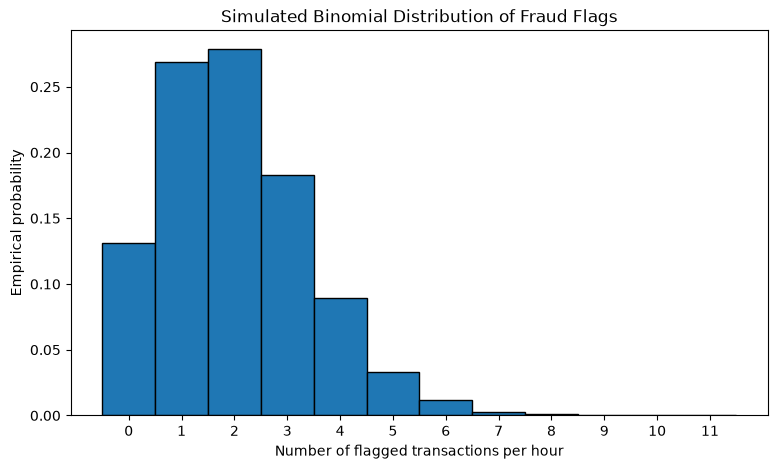

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))

plt.hist(
    flagged_transactions,
    bins=np.arange(
        flagged_transactions.max() + 2
    ) - 0.5,
    density=True,
    edgecolor="black"
)

plt.xlabel("Number of flagged transactions per hour")
plt.ylabel("Empirical probability")
plt.title("Simulated Binomial Distribution of Fraud Flags")
plt.xticks(range(flagged_transactions.max() + 1))
plt.show()

In [14]:
summary = pd.DataFrame({
    "Measure": [
        "Number of transactions per hour",
        "Flagging probability",
        "Number of simulated hours",
        "Theoretical mean",
        "Empirical mean",
        "Theoretical variance",
        "Empirical variance",
        "Investigation capacity",
        "Empirical P(X > 4)"
    ],
    "Value": [
        n_transactions,
        p_flag,
        n_hours,
        theoretical_mean_binomial,
        np.mean(flagged_transactions),
        theoretical_variance_binomial,
        np.var(flagged_transactions),
        capacity,
        empirical_probability_exceeding
    ]
})

summary

,Measure,Value
0,Number of transactions per hour,50.000000
1,Flagging probability,0.040000
2,Number of simulated hours,20000.000000
3,Theoretical mean,2.000000
4,Empirical mean,1.995750
5,Theoretical variance,1.920000
6,Empirical variance,1.922832
7,Investigation capacity,4.000000
8,Empirical P(X > 4),0.048300
